In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!git clone https://github.com/Radhika-Amar-Desai/BSF_implementation.git

fatal: destination path 'BSF_implementation' already exists and is not an empty directory.


In [3]:
!git clone https://github.com/facebookresearch/dinov3

fatal: destination path 'dinov3' already exists and is not an empty directory.


In [4]:
!cp -r /content/drive/MyDrive/data /content/BSF_implementation
# The following command to copy 'rabit_activations_dinov3' previously failed.
# If you intend to use pre-computed activations from this folder, please ensure it exists in MyDrive.
# !cp -r /content/drive/MyDrive/rabit_activations_dinov3/ /content/BSF_implementation/data

# Adding command to copy rabbit.npz from MyDrive to the data folder
# Please ensure 'rabbit.npz' is in the root of your Google Drive.
!cp /content/drive/MyDrive/rabbit.npz /content/BSF_implementation/data/

cp: cannot stat '/content/drive/MyDrive/rabbit.npz': No such file or directory


# Importing Important Modules

In [5]:
import os
os.chdir("/content/BSF_implementation")

In [6]:
!pwd

/content/BSF_implementation


In [7]:
import os
os.chdir("/content/BSF_implementation")

In [ ]:
import sys
from pathlib import Path

# Add the project root (parent of notebooks) to Python's search path
sys.path.append(str(Path().resolve().parent))

import os
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from models.SAE_with_l1_sparsity import build_model

In [9]:
# Install einops for data manipulation
!pip install einops

In [10]:
import sys
import pathlib
import numpy as np
import torch
from torchvision.transforms import v2
import einops

# Import data module from BSF_implementation for POS_MEAN and patch_grid
# This assumes 'data.py' or a 'data' package exists in the BSF_implementation directory.
# If this import fails, you might need to adjust the path or ensure the module is present.
try:
    import data
except ImportError:
    print("Warning: 'data' module not found. Assuming data.py or data package is in the BSF_implementation directory.")
    # Placeholder if data module is truly missing
    class DummyData:
        POS_MEAN = 0  # Placeholder, actual value needed
        def patch_grid(self, *args, **kwargs):
            print("Warning: patch_grid function not available. 'data' module not loaded.")
            return None
    data = DummyData()


DINO_REPO = "/content/dinov3"
WEIGHTS = "/content/drive/MyDrive/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"
ROOT = pathlib.Path('/content/BSF_implementation/data') # Assuming rabbit.npz is here

# Prepend the repository path so that hubconf.py can resolve internal modules
if DINO_REPO not in sys.path:
    sys.path.insert(0, DINO_REPO)

In [11]:
!pip install torchmetrics

In [12]:
import sys
import pathlib
import numpy as np
import torch
from torchvision.transforms import v2


POS_MEAN_PATH = '/content/BSF_implementation/pos_mean.npy'
# (n_patches, d)
POS_MEAN = np.load(POS_MEAN_PATH).astype(np.float32)

# Local repo settings
DINO_REPO = "/content/dinov3"
WEIGHTS = "/content/drive/MyDrive/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"

# 1. FIX: Prepend the repository path so that hubconf.py can resolve internal modules
if DINO_REPO not in sys.path:
    sys.path.insert(0, DINO_REPO)

def load_rabbit_images(npz_path):
    """Load the rabbit images as a (N, H, W, 3) uint8 array."""
    return np.load(npz_path)['arr_0']

@torch.no_grad()
def dino_activations(
    images,
    *,
    device=None,
    batch_size=64,
):
    """
    Parameters
    ----------
    images : ndarray
        (N,H,W,3) uint8

    Returns
    -------
    ndarray
        (N,196,768) float32 patch embeddings
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    if not pathlib.Path(WEIGHTS).exists():
        raise FileNotFoundError(
            f"Model weights not found at {WEIGHTS}. Please ensure the weights file "
            "'dinov3_vitb16_pretrain_lvd1689m.pth' is downloaded and placed in your Google Drive."
        )

    # 2. FIX: Initialize the empty backbone via Hub, then manually inject the state dict.
    # DINOv3's hubconf models do not directly accept a 'weights' string path argument.
    model = torch.hub.load(
        DINO_REPO,
        "dinov3_vitb16",
        source="local",
        pretrained=False  # Tells hubconf not to fetch from remote Meta servers
    )

    # Load and map the local pth checkpoint weights safely
    state_dict = torch.load(WEIGHTS, map_location="cpu")

    # Unwrap 'model' or 'teacher' key if saved from a training checkpoint wrapper
    if "model" in state_dict:
        state_dict = state_dict["model"]
    elif "teacher" in state_dict:
        state_dict = state_dict["teacher"]

    model.load_state_dict(state_dict, strict=True)
    model = model.to(device).eval()

    transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
    ])

    outputs = []

    for start in range(0, len(images), batch_size):
        batch = torch.stack(
            [transform(im) for im in images[start:start + batch_size]]
        ).to(device)

        feats = model.forward_features(batch)

        # Extract features (B, 196, 768) for ViT-B/16 @ 224x224
        patch_tokens = feats["x_norm_patchtokens"]
        outputs.append(patch_tokens.cpu())

    return torch.cat(outputs, dim=0).numpy()

def patch_grid(n_patches):
    """Side length of the square patch grid (14 for DINOv3 ViT-B/16 @ 224)."""
    g = int(round(n_patches ** 0.5))
    assert g * g == n_patches, f'{n_patches} patches is not a square grid'
    return g

# Rabbit images -> DINOv3 patch activations (fp32). Needs a GPU; ~1 min.
images = load_rabbit_images('/content/BSF_implementation/data/rabbit.npz')
acts = dino_activations(images)

# centre by the ImageNet per-position mean, flatten, scale so ||x|| ~ sqrt(d)
acts = acts - POS_MEAN
x = einops.rearrange(acts, 'n p d -> (n p) d')
x = x / np.sqrt((x ** 2).sum(1).mean()) * np.sqrt(x.shape[1])
grid = patch_grid(acts.shape[1])
print('activations:', x.shape, '  patch grid:', grid)

activations: (58800, 768)   patch grid: 14


# Configuration

In [13]:
# ACTIVATION_FOLDER = "data/rabit_activations_dinov3"
INPUT_DIM = 768
NUM_BLOCKS = 256
BLOCK_SIZE = 3
TOP_K = 8
BATCH_SIZE = 2048
LR = 3e-3
EPOCHS = 300
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Dataset

In [14]:
class PatchDataset(Dataset):

    def __init__(self, activations):

        # Directly use the provided activations instead of loading from a folder
        self.samples = activations

        print("PatchDataset initialized with shape:", self.samples.shape)

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        x = self.samples[idx]

        return torch.from_numpy(x).float()

# DataLoader

In [15]:
# Use the generated activations 'x' directly for the PatchDataset
dataset = PatchDataset(x)

train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

PatchDataset initialized with shape: (58800, 768)


# Model

In [16]:
model = build_model(
    input_dim=INPUT_DIM,
    latent_dim=INPUT_DIM,
)

model.to(DEVICE)

Sparse_Autoencoder(
  (W): Linear(in_features=768, out_features=768, bias=False)
  (D): Linear(in_features=768, out_features=768, bias=False)
)

# Optimizer

In [17]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
)

criterion = nn.MSELoss()

lambda_ = 1e-3

# Training Loop

In [18]:
history = []

best_loss = float("inf")

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    dead_block_counter = None

    for x in tqdm(train_loader):

        x = x.to(DEVICE)

        output = model(x)

        # reconstruction = output["reconstruction"]

        # loss = criterion(
        #     reconstruction,
        #     x,
        # )

        reconstruction = output["reconstruction"]

        ###################################
        # Reconstruction loss
        ###################################

        recon_loss = criterion(
            reconstruction,
            x,
        )

        ###################################
        # L1 sparsity penalty
        ###################################

        l1_penalty = output["z"].abs().mean()

        ###################################
        # Total loss
        ###################################

        loss = recon_loss + lambda_ * l1_penalty

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        ###################################
        # Dead blocks
        ###################################

        # mask = output["active_mask"]

        # if dead_block_counter is None:

        #     dead_block_counter = mask.sum(0)

        # else:

        #     dead_block_counter += mask.sum(0)

    epoch_loss = running_loss / len(train_loader)

    history.append(epoch_loss)

    # dead_blocks = (dead_block_counter == 0).sum().item()

    print(
        f"Epoch {epoch+1:03d}"
        f" | Loss = {epoch_loss:.6f}"
    )

    if epoch_loss < best_loss:

        best_loss = epoch_loss

        torch.save(
            model.state_dict(),
            "improved_vanilla_bsf_dinov3.pth",
        )

100%|██████████| 28/28 [00:00<00:00, 31.89it/s]


Epoch 001 | Loss = 0.473738


100%|██████████| 28/28 [00:00<00:00, 29.18it/s]


Epoch 002 | Loss = 0.213923


100%|██████████| 28/28 [00:01<00:00, 19.32it/s]


...

Epoch 298 | Loss = 0.021569


100%|██████████| 28/28 [00:00<00:00, 32.56it/s]


Epoch 299 | Loss = 0.018205


100%|██████████| 28/28 [00:00<00:00, 33.42it/s]

Epoch 300 | Loss = 0.012183


# Visualization Of Concepts / Blocks

In [19]:
inference_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

best_model_path = r"improved_vanilla_bsf_dinov3.pth"

# Load weights
state_dict = torch.load(best_model_path, map_location="cpu")
model.load_state_dict(state_dict)

device = torch.device("cpu")
model.to(device)
model.eval()

Sparse_Autoencoder(
  (W): Linear(in_features=768, out_features=768, bias=False)
  (D): Linear(in_features=768, out_features=768, bias=False)
)

In [20]:
!git pull origin main

From https://github.com/Radhika-Amar-Desai/BSF_implementation
 * branch            main       -> FETCH_HEAD
Already up to date.


Latent codes: (58800, 768)
Atoms: (768, 768)
Images: (300, 224, 224, 3)
Top concepts: [0]


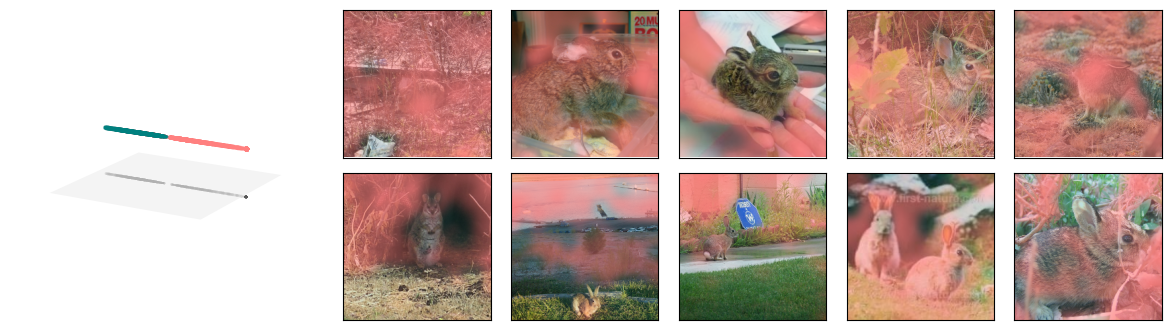

(58800, 768)
(300, 224, 224, 3)
[0]


In [22]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from PIL import Image
import matplotlib.pyplot as plt

from viz import plot_concepts_sae

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

NUM_IMAGES = 300
PATCHES_PER_IMAGE = 196 # Changed from 256 to 196 for DINOv3 ViT-B/16 (14x14 patches)

INPUT_DIM = 768
IMAGE_FOLDER = r"/content/drive/MyDrive/data/rabit_images"

# ------------------------------------------------------------
# Create dataloader
# ------------------------------------------------------------

loader = DataLoader(
    dataset,
    batch_size=256,
    shuffle=False,
    drop_last=False,
)

# ------------------------------------------------------------
# Run BSF
# ------------------------------------------------------------

model.eval()

all_z = []

with torch.no_grad():

    for features in loader:

        features = features.to(device)

        output = model(features)

        # (B,G,b)
        all_z.append(
            output["z"].cpu()
        )

# (512,4096,4)
z = torch.cat(all_z, dim=0).numpy()

print("Latent codes:", z.shape)

# ------------------------------------------------------------
# Extract decoder atoms
# ------------------------------------------------------------

# atoms = (
#     model.D.weight.detach()
#     .cpu()
#     .T
#     .reshape(
#         NUM_BLOCKS,
#         BLOCK_SIZE,
#         INPUT_DIM,
#     )
#     .numpy()
# )

atoms = (
    model.D.weight
    .detach()
    .cpu()
    .T
    .numpy()
)

print("Atoms:", atoms.shape)

# ------------------------------------------------------------
# Load only first two RGB images
# ------------------------------------------------------------

image_files = sorted(
    [
        f for f in os.listdir(IMAGE_FOLDER)
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg")
        )
    ]
)

images = []

for file in image_files[:NUM_IMAGES]:

    img = Image.open(
        os.path.join(
            IMAGE_FOLDER,
            file,
        )
    ).convert("RGB")

    images.append(np.asarray(img))

images = np.stack(images)

print("Images:", images.shape)

# ------------------------------------------------------------
# Automatically find the concepts that actually fired
# ------------------------------------------------------------

heat = np.linalg.norm(z, axis=-1)

concept_strength = heat.sum(axis=0)

top_concepts = np.argsort(-concept_strength)[:20]

print("Top concepts:", top_concepts)

# ------------------------------------------------------------
# Visualize
# ------------------------------------------------------------

fig = plot_concepts_sae(
    z=z,
    atoms=atoms,
    images=images,
    concepts=top_concepts,
    grid=14,
    n_img=10,
    ncol_img=5,
)

plt.show()

print(z.shape)
print(images.shape)
print(top_concepts)